# ADNI paired T1 / FA slices — loader sanity check

Loads slices through **the same pipeline as `train.py`** (`subject_level_split` → `val_split_from_train`
→ `PairedADNISliceDataset` → `DataLoader(shuffle=True)`), z = 40..49, label_4, seed 42,
and shows random pairs. Each row: T1, FA, FA contour overlaid on T1, with subject id and z.

In [1]:
import os, sys
ROOT = os.path.abspath('..') if os.path.basename(os.getcwd()) == 'exps' else os.getcwd()
sys.path.insert(0, ROOT)

import numpy as np, torch, matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from data import build_cache, PairedADNISliceDataset, subject_level_split
from train import val_split_from_train

SEED, Z_LO, Z_HI, SCHEME = 42, 40, 49, 'label_4'
build_cache()
tr_idx, te_idx = subject_level_split(SEED, 0.20, SCHEME, Z_LO, Z_HI)
tr_idx, va_idx = val_split_from_train(tr_idx, SEED, 0.15)
splits = {'train': tr_idx, 'val': va_idx, 'test': te_idx}
print({k: len(v) for k, v in splits.items()})

/home/siyuan/anaconda3/envs/brain/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  [z-restrict 40..49] -> train 1700 / test 430 slices
  split[label_4]: train=170 subj / 1700 slices  test=43 subj / 430 slices  (dropped 1 subj with invalid label)
{'train': 1440, 'val': 260, 'test': 430}


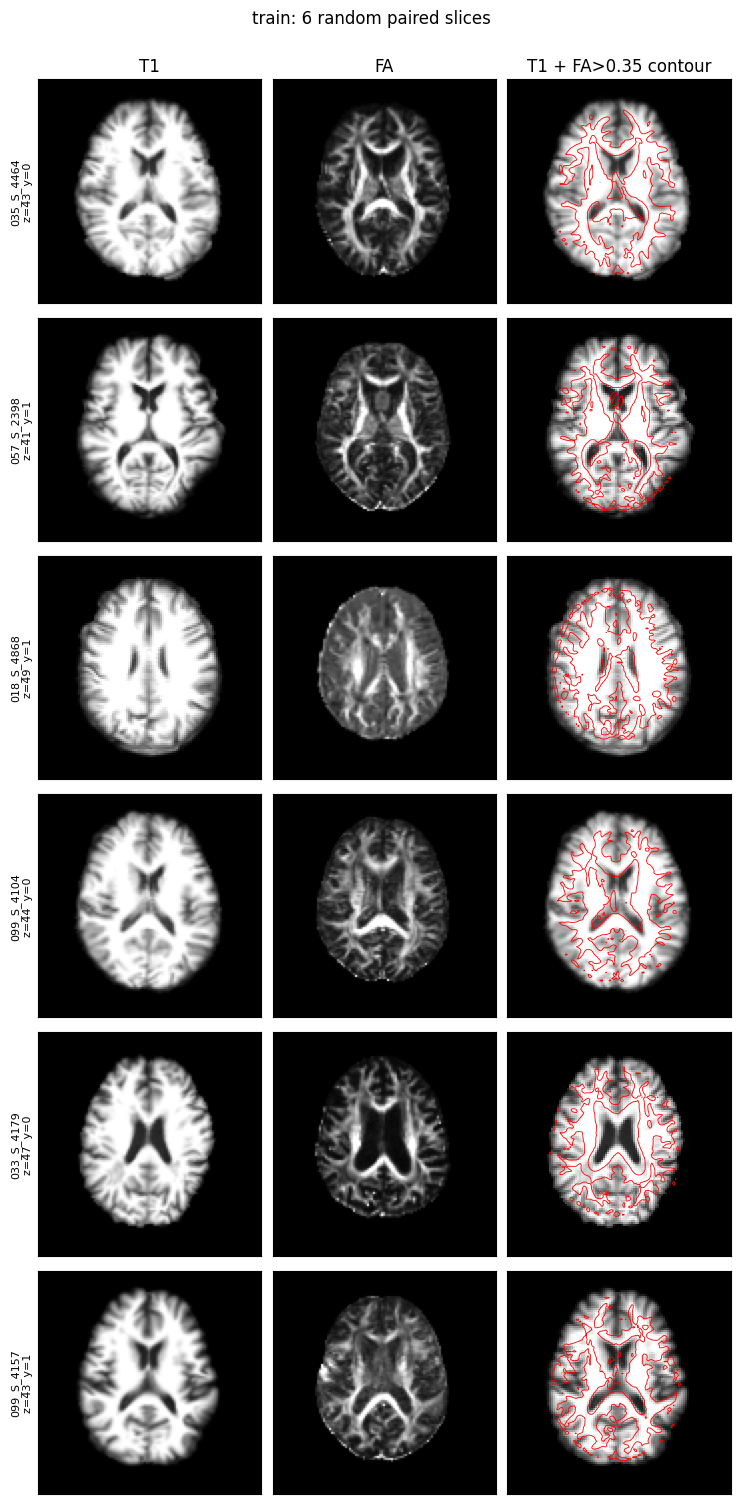

In [2]:
# the loader returns (T1, FA, label); wrap the index so we can also show subject / z
class WithIndex(PairedADNISliceDataset):
    def __getitem__(self, i):
        k = int(self.indices[i])
        return self.T1[k], self.FA[k], int(self.labels[k]), k

def show(split='train', n=6, seed=None):
    ds = WithIndex(splits[split], SCHEME)
    g = torch.Generator().manual_seed(seed) if seed is not None else None
    t1, fa, y, k = next(iter(DataLoader(ds, batch_size=n, shuffle=True, generator=g)))
    fig, ax = plt.subplots(n, 3, figsize=(7.5, 2.5 * n))
    for r in range(n):
        s = ds.subjects[int(ds.subj_idx[k[r]])]; z = int(ds.z_idx[k[r]])
        a, b = t1[r, 0].numpy(), fa[r, 0].numpy()
        ax[r, 0].imshow(a, cmap='gray', vmin=0, vmax=1); ax[r, 0].set_ylabel(f'{s}\nz={z}  y={int(y[r])}', fontsize=8)
        ax[r, 1].imshow(b, cmap='gray', vmin=0, vmax=1)
        ax[r, 2].imshow(a, cmap='gray', vmin=0, vmax=1)
        ax[r, 2].contour(b, levels=[0.35], colors='r', linewidths=0.6)
        for c in range(3): ax[r, c].set_xticks([]); ax[r, c].set_yticks([])
    for c, t in enumerate(['T1', 'FA', 'T1 + FA>0.35 contour']): ax[0, c].set_title(t)
    fig.suptitle(f'{split}: {n} random paired slices', y=1.0); fig.tight_layout(); plt.show()

show('train', seed=0)

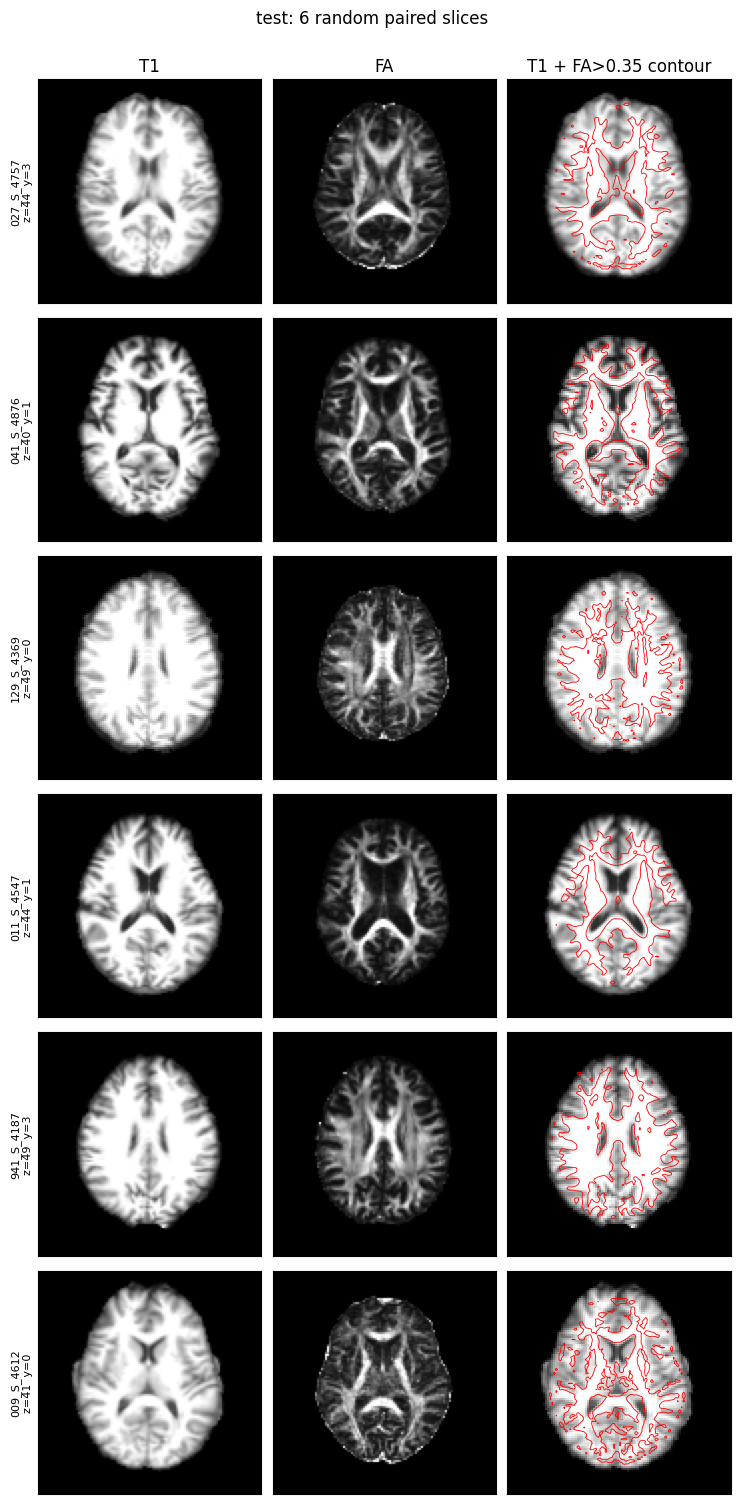

In [3]:
show('test', seed=1)

### Mismatch control
Same slice position, **different subject** FA next to the true FA — the white-matter pattern
in the overlay should fit the paired one visibly better.

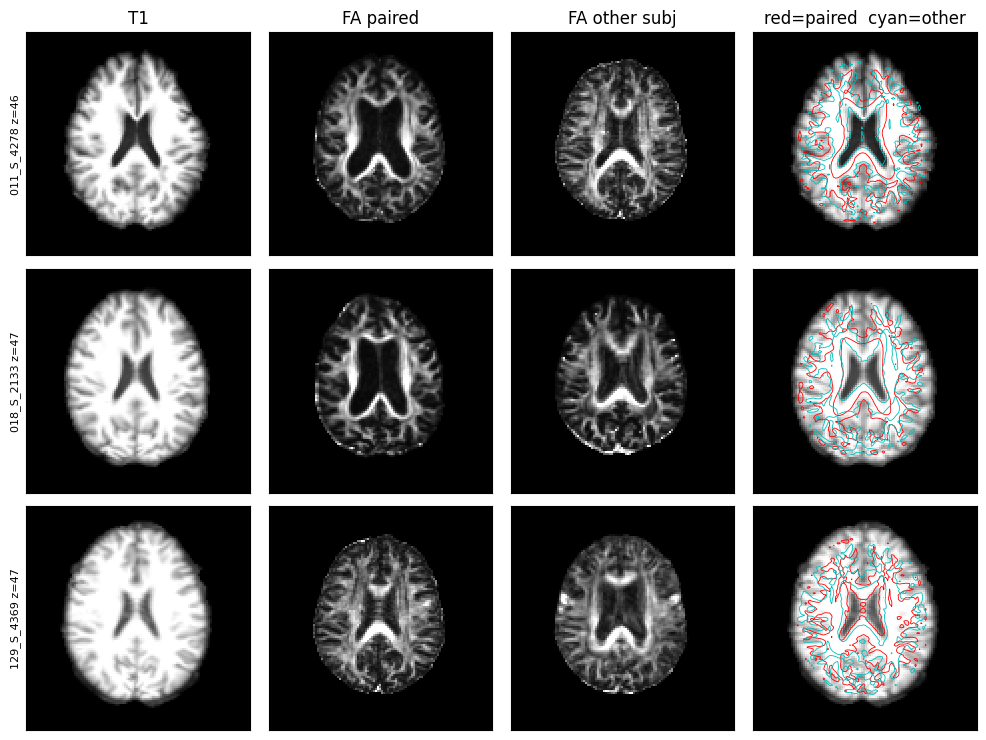

In [4]:
ds = WithIndex(splits['test'], SCHEME)
rng = np.random.default_rng(3)
sid, zid = ds.subj_idx.numpy(), ds.z_idx.numpy()
pool = ds.indices.numpy()
fig, ax = plt.subplots(3, 4, figsize=(10, 7.5))
for r, k in enumerate(rng.choice(pool, 3, replace=False)):
    j = rng.choice(pool[(zid[pool] == zid[k]) & (sid[pool] != sid[k])])
    for c, (img, t) in enumerate([(ds.T1[k, 0], 'T1'), (ds.FA[k, 0], 'FA paired'), (ds.FA[j, 0], 'FA other subj')]):
        ax[r, c].imshow(img, cmap='gray', vmin=0, vmax=1); ax[r, c].set_title(t if r == 0 else '')
    ax[r, 3].imshow(ds.T1[k, 0], cmap='gray', vmin=0, vmax=1)
    ax[r, 3].contour(ds.FA[k, 0], levels=[0.35], colors='r', linewidths=0.6)
    ax[r, 3].contour(ds.FA[j, 0], levels=[0.35], colors='c', linewidths=0.6)
    ax[r, 0].set_ylabel(f'{ds.subjects[sid[k]]} z={zid[k]}', fontsize=8)
    if r == 0: ax[r, 3].set_title('red=paired  cyan=other')
for a in ax.flat: a.set_xticks([]); a.set_yticks([])
fig.tight_layout(); plt.show()